# Rethinking Style Transfer: From Pixels to Parameterized Brushstrokes

**Kotovenko et al., CVPR 2021** — [Paper](https://arxiv.org/abs/2103.17185)

This notebook implements the core pipeline from the paper:

**Brushstroke optimization**: Optimize parametric brushstrokes (quadratic Bezier curves) rendered via a differentiable renderer, guided by VGG content + style losses.


Each brushstroke is parameterized by: location, start/end/control points (Bezier curve), color (RGB), and width. The differentiable renderer composites strokes onto a canvas using distance-based alpha masks and soft nearest-neighbor ranking.

## Setup & Imports

In [17]:
import os
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import functional as TF
from torchvision.utils import save_image
from IPython.display import display

from renderer import BrushStrokeRenderer
from losses import StyleTransferLosses, total_variation_loss, curvature_loss
from utils import image_loader

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Configuration

Adjust paths, hyperparameters, and VGG layers below.

In [18]:
# PATHS ###################################################
# Adjust content and style image paths as needed
CONTENT_IMG_PATH = "images/content/golden_gate.jpg" 
STYLE_IMG_PATH   = "images/style/starry_night.jpg"
OUTPUT_DIR       = "results"
VGG_WEIGHTS      = "vgg_weights/vgg19_weights_normalized.h5"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs("images/content", exist_ok=True)
os.makedirs("images/style", exist_ok=True)

# IMAGE SETTINGS ###########################################
IMG_SIZE         = 512
CANVAS_COLOR     = "gray"    # "gray", "white", or "black"

# BRUSHSTROKE RENDERER SETTINGS ###########################
NUM_STROKES      = 5000      # total number of brushstrokes
SAMPLES_PER_CURVE = 10       # points sampled per Bezier curve
BRUSHES_PER_PIXEL = 20       # K nearest strokes considered per pixel
LENGTH_SCALE     = 1.1       # controls stroke length at init
WIDTH_SCALE      = 0.1       # controls stroke width at init

# BRUSHSTROKE OPTIMIZATION HYPERPARAMETERS ##################
BS_STEPS         = 100
BS_CONTENT_WEIGHT = 1.0
BS_STYLE_WEIGHT  = 3.0
BS_TV_WEIGHT     = 0.008
BS_CURV_WEIGHT   = 4.0
BS_LR_GEOM       = 1e-1     # learning rate for geometry params
BS_LR_COLOR      = 1e-2     # learning rate for color

# VGG LAYERS FOR LOSSES #####################################
# Uses the same layers as Gatys et al.
BS_CONTENT_LAYERS = ["conv4_2", "conv5_2"]
BS_STYLE_LAYERS   = ["conv1_1", "conv2_1", "conv3_1", "conv4_1", "conv5_1"]

## Load Content & Style Images

Content: torch.Size([1, 3, 512, 682])  Style: torch.Size([1, 3, 224, 282])


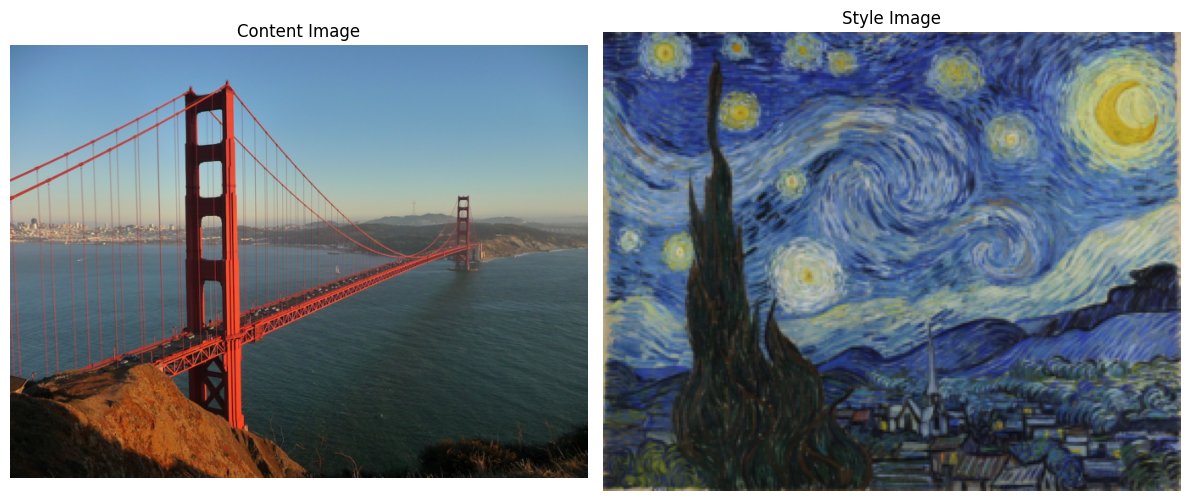

In [19]:
content_img = image_loader(CONTENT_IMG_PATH, IMG_SIZE, device)
style_img   = image_loader(STYLE_IMG_PATH, 224, device)

print(f"Content: {content_img.shape}  Style: {style_img.shape}")
_, _, H, W = content_img.shape

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(content_img[0].permute(1, 2, 0).cpu())
axes[0].set_title("Content Image")
axes[0].axis("off")
axes[1].imshow(style_img[0].permute(1, 2, 0).cpu())
axes[1].set_title("Style Image")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Stage 1: Brushstroke Optimization

Optimize N brushstrokes parameterized as quadratic Bezier curves. Each stroke has:
- **Location** $(x, y)$: center position on canvas
- **Bezier control points** $(s, c, e)$: start, control, end — relative to location
- **Color** $(r, g, b)$: RGB values in $[0, 1]$
- **Width** $w$: stored in log-space

Two separate Adam optimizers are used:
- **Geometry optimizer** (lr=0.1): location, curve points, width — driven by content + style + TV + curvature losses
- **Color optimizer** (lr=0.01): color — driven by style loss only

In [20]:
# Build VGG loss module for brushstroke stage
vgg_loss_bs = StyleTransferLosses(
    VGG_WEIGHTS, content_img, style_img,
    BS_CONTENT_LAYERS, BS_STYLE_LAYERS, scale_by_y=True,
)
vgg_loss_bs.to(device).eval()

# Initialize brushstroke renderer from content image (SLIC superpixels)
content_np = content_img[0].permute(1, 2, 0).cpu().numpy()
bs_renderer = BrushStrokeRenderer(
    H, W,
    num_strokes=NUM_STROKES,
    samples_per_curve=SAMPLES_PER_CURVE,
    strokes_per_pixel=BRUSHES_PER_PIXEL,
    canvas_color=CANVAS_COLOR,
    length_scale=LENGTH_SCALE,
    width_scale=WIDTH_SCALE,
    content_img=content_np,
)
bs_renderer.to(device)
print(f"Initialized {bs_renderer.location.shape[0]} brushstrokes on {H}x{W} canvas")

VGG19 weights loaded.
Initialized 6408 brushstrokes on 512x682 canvas


In [21]:
# Two optimizers: geometry at higher LR, color at lower LR
optimizer_geom = optim.Adam(
    [bs_renderer.location, bs_renderer.curve_s, bs_renderer.curve_e,
     bs_renderer.curve_c, bs_renderer.width],
    lr=BS_LR_GEOM,
)
optimizer_color = optim.Adam([bs_renderer.color], lr=BS_LR_COLOR)

# Loss tracking
bs_losses = {"content": [], "style": [], "tv": [], "curvature": [], "total": []}

print(f"Optimizing brushstrokes for {BS_STEPS} steps...")
for step in range(1, BS_STEPS + 1):
    optimizer_geom.zero_grad()
    optimizer_color.zero_grad()

    # Render canvas from current brushstroke parameters
    canvas = bs_renderer()                                          # [H, W, 3]
    canvas_img = canvas.unsqueeze(0).permute(0, 3, 1, 2).contiguous()  # [1, 3, H, W]

    # Compute VGG content & style losses
    content_loss, style_loss = vgg_loss_bs(canvas_img)
    content_loss = content_loss * BS_CONTENT_WEIGHT
    style_loss   = style_loss * BS_STYLE_WEIGHT

    # Brushstroke regularization losses
    tv_loss = BS_TV_WEIGHT * total_variation_loss(
        bs_renderer.location, bs_renderer.curve_s, bs_renderer.curve_e, K=10
    )
    curv_loss = BS_CURV_WEIGHT * curvature_loss(
        bs_renderer.curve_s, bs_renderer.curve_e, bs_renderer.curve_c
    )

    # Backward pass for geometry parameters (all losses)
    loss = content_loss + style_loss + tv_loss + curv_loss
    loss.backward(
        inputs=[bs_renderer.location, bs_renderer.curve_s, bs_renderer.curve_e,
                bs_renderer.curve_c, bs_renderer.width],
        retain_graph=True,
    )
    optimizer_geom.step()

    # Backward pass for color (style loss only)
    style_loss.backward(inputs=[bs_renderer.color])
    optimizer_color.step()

    # Track losses
    bs_losses["content"].append(content_loss.item())
    bs_losses["style"].append(style_loss.item())
    bs_losses["tv"].append(tv_loss.item())
    bs_losses["curvature"].append(curv_loss.item())
    bs_losses["total"].append(loss.item())

    if step % 10 == 0 or step == 1:
        print(
            f"  Step {step:4d} | content={content_loss.item():.4f} "
            f"style={style_loss.item():.4f} tv={tv_loss.item():.4f} "
            f"curv={curv_loss.item():.4f}"
        )

    # Save intermediate results
    if step % 25 == 0:
        save_image(canvas_img, os.path.join(OUTPUT_DIR, f"stroke_step_{step:04d}.png"))

print("Brushstroke optimization complete.")

Optimizing brushstrokes for 100 steps...
  Step    1 | content=3.8683 style=21.3833 tv=402.6914 curv=0.7204
  Step   10 | content=3.9048 style=8.8264 tv=251.2788 curv=0.3988
  Step   20 | content=4.1265 style=5.3874 tv=152.8414 curv=0.4501
  Step   30 | content=4.2220 style=3.9743 tv=95.9016 curv=0.4720
  Step   40 | content=4.2665 style=3.1408 tv=62.6116 curv=0.4714
  Step   50 | content=4.2954 style=2.7207 tv=42.7553 curv=0.4581
  Step   60 | content=4.3196 style=2.3702 tv=31.0819 curv=0.4430
  Step   70 | content=4.3520 style=2.1223 tv=23.7916 curv=0.4264
  Step   80 | content=4.3641 style=2.0175 tv=18.9027 curv=0.4131
  Step   90 | content=4.3804 style=1.9183 tv=15.6224 curv=0.4029
  Step  100 | content=4.4057 style=1.8304 tv=13.2709 curv=0.3954
Brushstroke optimization complete.


### Brushstroke Stage Results

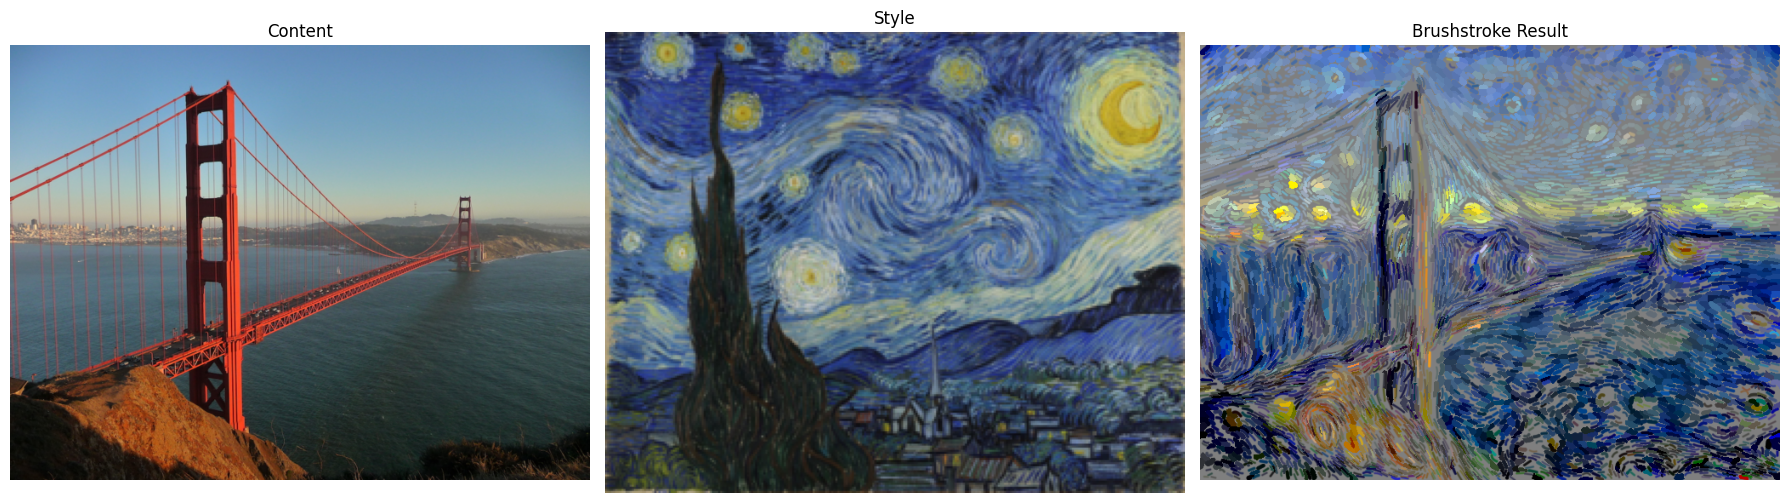

In [23]:
# Visualize brushstroke optimization result
with torch.no_grad():
    final_canvas_bs = bs_renderer()  # [H, W, 3]
    final_canvas_img = final_canvas_bs.unsqueeze(0).permute(0, 3, 1, 2)
    save_image(final_canvas_img, os.path.join(OUTPUT_DIR, "brushstroke_result.png"))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(content_img[0].permute(1, 2, 0).cpu())
axes[0].set_title("Content")
axes[0].axis("off")
axes[1].imshow(style_img[0].permute(1, 2, 0).cpu())
axes[1].set_title("Style")
axes[1].axis("off")
axes[2].imshow(final_canvas_bs.cpu().numpy().clip(0, 1))
axes[2].set_title("Brushstroke Result")
axes[2].axis("off")
plt.tight_layout()
plt.show()

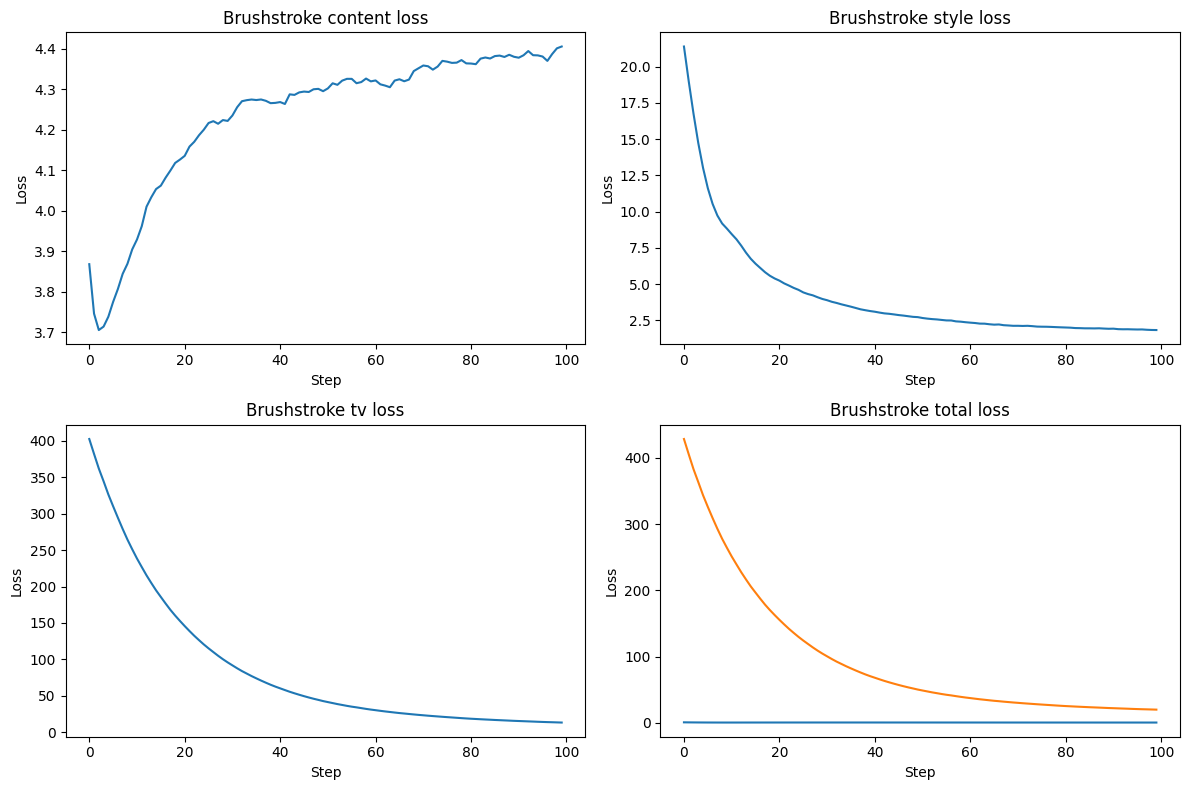

In [24]:
# Plot loss curves
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, vals) in zip(axes.flatten(), bs_losses.items()):
    if name == "total":
        continue
    ax.plot(vals)
    ax.set_title(f"Brushstroke {name} loss")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
axes[1, 1].plot(bs_losses["total"])
axes[1, 1].set_title("Brushstroke total loss")
axes[1, 1].set_xlabel("Step")
axes[1, 1].set_ylabel("Loss")
plt.tight_layout()
plt.show()

## Deception Score Evaluation

The **deception rate** measures stylization quality using a VGG-16 network trained to classify WikiArt paintings into 624 artists (Sanakoyeu et al.). For each stylized image, we check whether the classifier assigns it to the target artist. The deception rate is the fraction of images that "fool" the classifier.

The pretrained TF checkpoint is automatically converted to PyTorch on first run.

In [ ]:
from deception_score import load_deception_model, compute_deception_rate, get_artist_labels, ARTISTS

# Load the artist classifier directly from TF checkpoint
deception_model = load_deception_model(ckpt_dir="deception_score_vgg")

# Print available artists and their labels
artist_labels = get_artist_labels("deception_score_vgg/split.hdf5")
print("Available artists for deception score:")
for artist, label in sorted(artist_labels.items(), key=lambda x: x[1]):
    print(f"  {artist}: label {label}")

In [ ]:
# ── Evaluate deception rate on the brushstroke result ──────────────

# Set the target artist that matches your style image.
# Must be one of the ARTISTS listed above (e.g. "vincent-van-gogh" for Starry Night).
TARGET_ARTIST = "vincent-van-gogh"  # <-- change to match your style image's artist

# Evaluate using the rendered canvas tensor directly
with torch.no_grad():
    result_tensor = final_canvas_img.clone()  # [1, 3, H, W] from brushstroke stage

deception_rate, details = compute_deception_rate(
    deception_model,
    [result_tensor],
    target_artist=TARGET_ARTIST,
    split_hdf5_path="deception_score_vgg/split.hdf5",
)

print(f"Target artist: {TARGET_ARTIST} (label {details['target_label']})")
print(f"Predicted label: {details['predictions'][0]}")
print(f"Deception rate: {deception_rate:.2%} ({details['correct']}/{details['total']})")

# Also evaluate any saved results from the output directory
import glob
saved_results = sorted(glob.glob(os.path.join(OUTPUT_DIR, "stroke_step_*.png"))) + \
                glob.glob(os.path.join(OUTPUT_DIR, "brushstroke_result.png"))

if len(saved_results) > 1:
    deception_rate_all, details_all = compute_deception_rate(
        deception_model,
        saved_results,
        target_artist=TARGET_ARTIST,
        split_hdf5_path="deception_score_vgg/split.hdf5",
    )
    print(f"\nDeception rate across all saved outputs: {deception_rate_all:.2%} "
          f"({details_all['correct']}/{details_all['total']})")
    print("Per-image predictions:", details_all['predictions'])